# <div style="text-align: center; background-color: white; font-family: Lobster;color: black; padding: 14px; line-height: 1;border-radius:12px"> Import Libraries </div>

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# <div style="text-align: center; background-color: white; font-family: Lobster;color: black; padding: 14px; line-height: 1;border-radius:12px"> Load Data </div>

In [21]:
posts_path =r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\processed\posts.csv"
comments_path = r'C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\processed\posts_comments.csv'
post_df = pd.read_csv(posts_path)
comment_df = pd.read_csv(comments_path, sep=',')

# Drop column type and image
post_df = post_df.drop(columns=['image'])
comment_df = comment_df.drop(columns=['likes'])

In [22]:
post_df.rename(columns={'ownerUsername': 'postUser'}, inplace=True)
post_df.head()

,post_id,timestamp,postUser,caption,hashtags,likesCount,commentsCount
0,1,2023-06-02 16:34:43+00:00,maryleest,Cannes 2023 with @kilianparis 🤍 #KilianCannes ...,KilianCannes,32070,142
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,"As the clock struck midnight to ring in 2022, ...",NaN,6565,86
2,3,2023-05-29 18:57:51+00:00,maryleest,The famous stairs 🤎 Photo @gustave_durin Dre...,NaN,28936,123
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,I visualized this moment so many times before....,CHANELFallWinter,4764,215
4,5,2023-05-23 21:11:12+00:00,maryleest,Got to witness such historical moment in cinem...,CannesFilmFestival,13379,123


# <div style="text-align: center; background-color: white; font-family: Lobster;color: black; padding: 14px; line-height: 1;border-radius:12px"> Data Cleaning </div>

In [23]:
def overall(df):
    print ("Rows : " ,df.shape[0])
    print ("Columns : " ,df.shape[1])
    print ("\nFeatures : \n" ,df.columns.tolist())
    print ("\nMissing values : ", df.isnull().sum().values.sum())
    print ("\nUnique values : \n", df.nunique())

### Posts

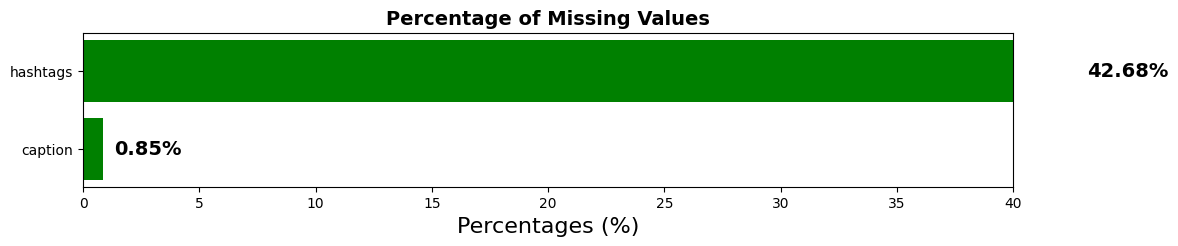

In [24]:
# Calculating the percentage of missing values for each column
missing_data = post_df.isnull().sum()
missing_percentage = (missing_data[missing_data > 0] / post_df.shape[0]) * 100

# Prepare values
missing_percentage.sort_values(ascending=True, inplace=True)

# Plot the barh chart
fig, ax = plt.subplots(figsize=(12, 2))
ax.barh(missing_percentage.index, missing_percentage, color='green')

# Annotate the values and indexes
for i, (value, name) in enumerate(zip(missing_percentage, missing_percentage.index)):
    ax.text(value+0.5, i, f"{value:.2f}%", ha='left', va='center', fontweight='bold', fontsize=14, color='black')

# Set x-axis limit
ax.set_xlim([0, 40])

# Add title and xlabel
plt.title("Percentage of Missing Values", fontweight='bold', fontsize=14)
plt.xlabel('Percentages (%)', fontsize=16)
plt.show()

In [25]:
overall(post_df)

Rows :  827
Columns :  7

Features : 
 ['post_id', 'timestamp', 'postUser', 'caption', 'hashtags', 'likesCount', 'commentsCount']

Missing values :  360

Unique values : 
 post_id          827
timestamp        827
postUser          48
caption          777
hashtags         359
likesCount       787
commentsCount    358
dtype: int64


In [26]:
# Fill missing value in caption and hashtags column by ""
post_df['caption'] = post_df['caption'].fillna('no_caption')
post_df['hashtags'] = post_df['hashtags'].fillna('no_hashtag')

In [27]:
post_df.isnull().sum()

post_id          0
timestamp        0
postUser         0
caption          0
hashtags         0
likesCount       0
commentsCount    0
dtype: int64

### Comments

In [28]:
comment_df.rename(columns={'ownerUsername': 'commentUser'}, inplace=True)
comment_df.head()

,post_id,commentUser,timestamp,comments
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!"
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...


In [29]:
overall(comment_df)

Rows :  5432
Columns :  4

Features : 
 ['post_id', 'commentUser', 'timestamp', 'comments']

Missing values :  242

Unique values : 
 post_id         827
commentUser    4089
timestamp      5344
comments       3918
dtype: int64


In [30]:
comment_df['comments'] = comment_df['comments'].fillna('no_comment')

In [31]:
comment_df = comment_df.dropna(subset=['commentUser'])

In [32]:
comment_df.isnull().sum()

post_id        0
commentUser    0
timestamp      0
comments       0
dtype: int64

### Time format

In [33]:
# Type of each column
post_df['timestamp'] = pd.to_datetime(post_df['timestamp'])
comment_df['timestamp'] = pd.to_datetime(comment_df['timestamp'])


In [34]:
post_df.head()

,post_id,timestamp,postUser,caption,hashtags,likesCount,commentsCount
0,1,2023-06-02 16:34:43+00:00,maryleest,Cannes 2023 with @kilianparis 🤍 #KilianCannes ...,KilianCannes,32070,142
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,"As the clock struck midnight to ring in 2022, ...",no_hashtag,6565,86
2,3,2023-05-29 18:57:51+00:00,maryleest,The famous stairs 🤎 Photo @gustave_durin Dre...,no_hashtag,28936,123
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,I visualized this moment so many times before....,CHANELFallWinter,4764,215
4,5,2023-05-23 21:11:12+00:00,maryleest,Got to witness such historical moment in cinem...,CannesFilmFestival,13379,123


In [35]:
comment_df.head()

,post_id,commentUser,timestamp,comments
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!"
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...


In [ ]:
#comment_df.to_csv('clean_comments.csv', index=False)
#post_df.to_csv('clean_posts.csv', index=False)